En este análisis exploratorio se estudiaron los datos de Airbnb con el objetivo de identificar patrones de precios, disponibilidad y comportamiento de reseñas.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../data/listings_clean.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23729 entries, 0 to 23728
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         23729 non-null  int64  
 1   host_id                    23729 non-null  int64  
 2   host_since                 23726 non-null  str    
 3   host_response_time         23729 non-null  str    
 4   host_response_rate         23729 non-null  float64
 5   host_acceptance_rate       23729 non-null  float64
 6   host_is_superhost          23729 non-null  float64
 7   host_total_listings_count  23726 non-null  float64
 8   host_identity_verified     23726 non-null  str    
 9   neighbourhood_cleansed     23729 non-null  str    
 10  city                       23142 non-null  str    
 11  latitude                   23729 non-null  float64
 12  longitude                  23729 non-null  float64
 13  property_type              23729 non-null  str    
 14  r

In [4]:
# estadistica descriptiva general

df.describe()

,id,host_id,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,latitude,longitude,accommodates,bathrooms,...,number_of_reviews_ltm,review_scores_rating,instant_bookable,reviews_per_month,listing_id,reviews_count,years_active,host_years,occupancy_rate,estimated_revenue
count,2.372900e+04,2.372900e+04,23729.000000,23729.000000,23729.000000,23726.000000,23729.000000,23729.000000,23729.000000,23729.000000,...,23729.000000,23729.000000,23729.000000,23729.000000,1.722200e+04,17222.000000,17222.000000,23726.000000,23729.000000,2.372900e+04
mean,2.668555e+07,1.052637e+08,64.851658,68.497493,0.279911,9.765869,-34.592575,-58.415900,2.761768,1.258565,...,6.299254,67.169244,0.505415,0.764750,2.516912e+07,22.477006,1.389256,10.314254,0.426346,5.328787e+05
std,1.263388e+07,9.990251e+07,45.485753,41.805338,0.448965,70.044391,0.018282,0.029925,1.480604,0.630942,...,11.242998,43.614735,0.499981,1.093005,1.249784e+07,36.068447,1.718668,2.461154,0.378059,2.949938e+06
min,1.150800e+04,2.616000e+03,0.000000,0.000000,0.000000,0.000000,-34.688950,-58.530200,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.150800e+04,1.000000,0.000000,6.000000,0.000000,0.000000e+00
25%,1.765680e+07,1.546679e+07,0.000000,18.000000,0.000000,1.000000,-34.603430,-58.435380,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.610621e+07,3.000000,0.161644,8.000000,0.005479,6.372000e+03
50%,3.000878e+07,6.886052e+07,100.000000,95.000000,0.000000,1.000000,-34.591890,-58.415160,2.000000,1.000000,...,1.000000,94.000000,1.000000,0.310000,2.848737e+07,9.000000,0.760274,10.000000,0.506849,2.403680e+05
75%,3.736241e+07,1.841516e+08,100.000000,100.000000,1.000000,4.000000,-34.582150,-58.391750,4.000000,1.500000,...,7.000000,99.000000,1.000000,1.060000,3.519465e+07,26.000000,1.895890,12.000000,0.756164,5.573550e+05
max,4.328606e+07,3.445900e+08,100.000000,100.000000,1.000000,1511.000000,-34.534100,-58.355410,16.000000,30.000000,...,125.000000,100.000000,1.000000,10.730000,4.308488e+07,500.000000,9.873973,18.000000,1.000000,2.415984e+08


El dataset contiene 23.729 propiedades de Airbnb, con información sobre características de las propiedades, hosts, precios, disponibilidad y reviews.

1. Vista general del Dataset

In [5]:
# Propiedades por barrio
df["neighbourhood_cleansed"].value_counts().head(10)

neighbourhood_cleansed
Palermo         7149
Recoleta        3920
San Nicolas     1377
Retiro          1244
Balvanera       1153
Belgrano        1100
Monserrat       1006
Almagro          979
Villa Crespo     770
San Telmo        736
Name: count, dtype: int64

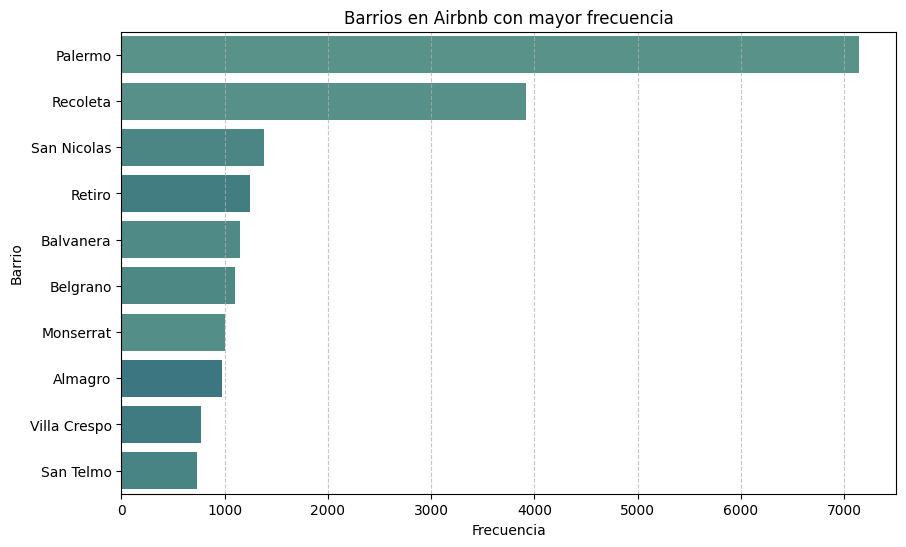

In [6]:
# Visualización de los barrios mas comunes
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y="neighbourhood_cleansed",
    order=df["neighbourhood_cleansed"].value_counts().index[:10],
    palette="crest_d",
    hue="neighbourhood_cleansed"
)
plt.title("Barrios en Airbnb con mayor frecuencia")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlabel("Frecuencia")
plt.ylabel("Barrio")
plt.show()

Palermo tiene casi el doble de oferta que Recoleta (el segundo top). Para un inversor esto significa mucha competencia en esas zonas pero también una demanda validada.

In [7]:
# Tipos de propiedad
df["property_type"].value_counts().head(10)

property_type
Apartment             19534
House                  1684
Loft                    797
Condominium             619
Serviced apartment      348
Bed and breakfast       145
Hostel                   98
Guest suite              89
Guesthouse               72
Other                    65
Name: count, dtype: int64

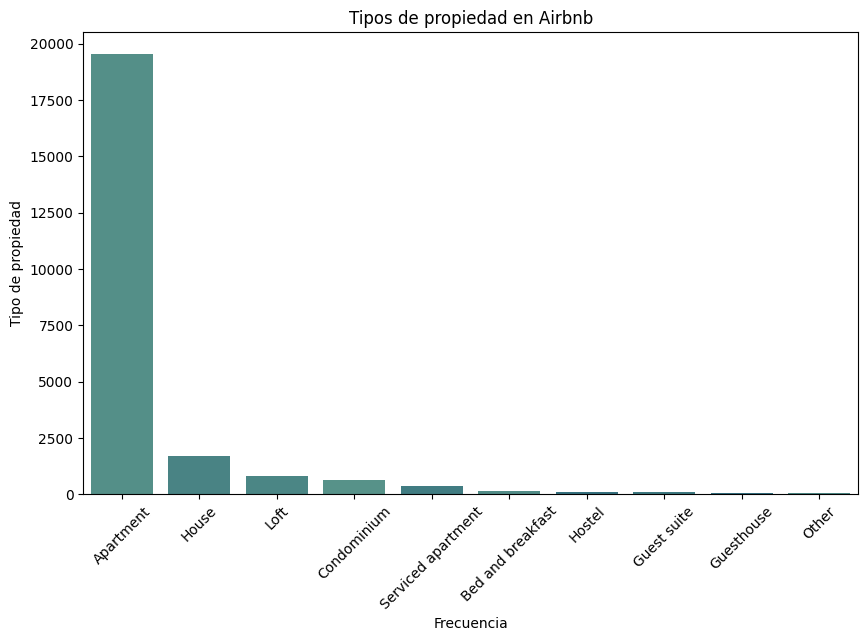

In [8]:
# Visualización de Top 15 tipos de propiedad
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="property_type",
    order=df["property_type"].value_counts().index[:10],
    palette="crest_d",
    hue="property_type"
)
plt.title("Tipos de propiedad en Airbnb")
plt.xlabel("Frecuencia")
plt.ylabel("Tipo de propiedad")
plt.xticks(rotation=45)
plt.show()

Existe mayor cantidad de propiedades de tipo Apartment.

2. Análisis de precios

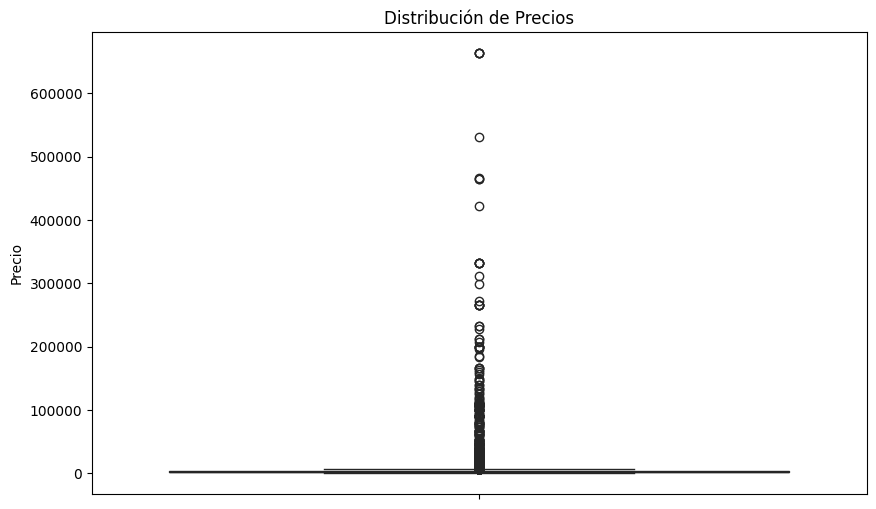

In [9]:
# Distribución de precios
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['price'], color="teal")
plt.title('Distribución de Precios')
plt.ylabel('Precio')
plt.show()


Existe una dispersión extrema. La mediana ronda los $2000 y hay valores que llegan a $600000.

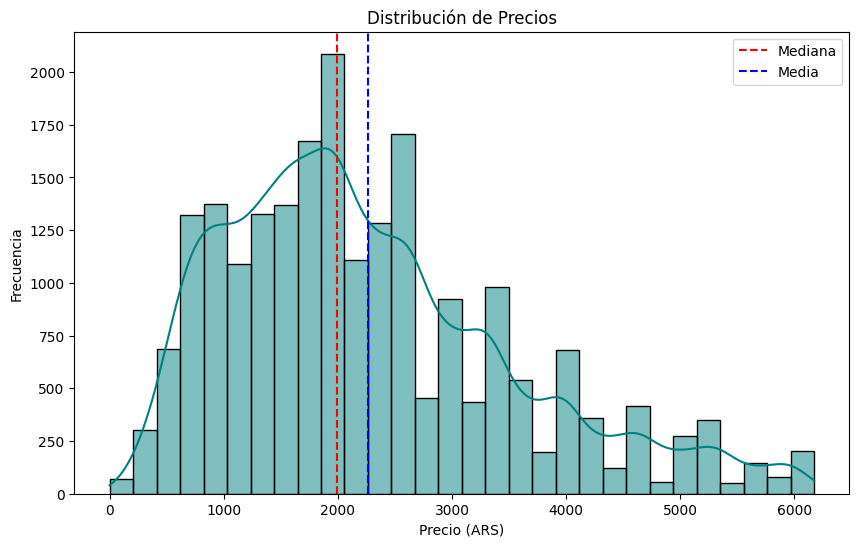

In [10]:
# eliminacion de outliers en la columna "price" utilizando el método del rango intercuartílico (IQR)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

# Distribución de precios después de eliminar outliers
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True, color="teal")
plt.axvline(df['price'].median(), color='red', linestyle='--', label='Mediana')
plt.axvline(df['price'].mean(), color='blue', linestyle='--', label='Media')
plt.title('Distribución de Precios')
plt.xlabel('Precio (ARS)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


In [11]:
print("media: ", df["price"].mean())
print("mediana: ", df["price"].median())

media:  2261.321291633945
mediana:  1991.0


- Distribución con sesgo positivo (media > mediana) existe un grupo chico de propiedades con precios elevados.
- Los precios se concentran entre $1000 a $3000

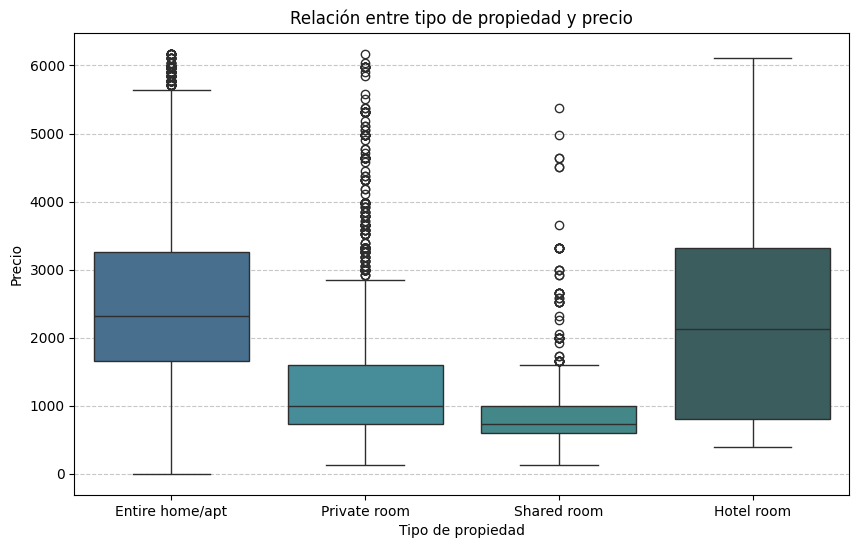

In [12]:
# Relación entre tipo de propiedad y precio
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="room_type",
    y="price", 
    palette="mako_d",
    hue="room_type"
)
plt.title("Relación entre tipo de propiedad y precio")
plt.xlabel("Tipo de propiedad")
plt.ylabel("Precio")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- El tipo de propiedad influye significativamente en el precio de los alojamientos. 
- Las propiedades Entire home/apt presentan los precios más altos, mientras que las habitaciones privadas y compartidas son más económicas. Esto sugiere que el nivel de privacidad y espacio ofrecido es un factor clave en la determinación del precio.

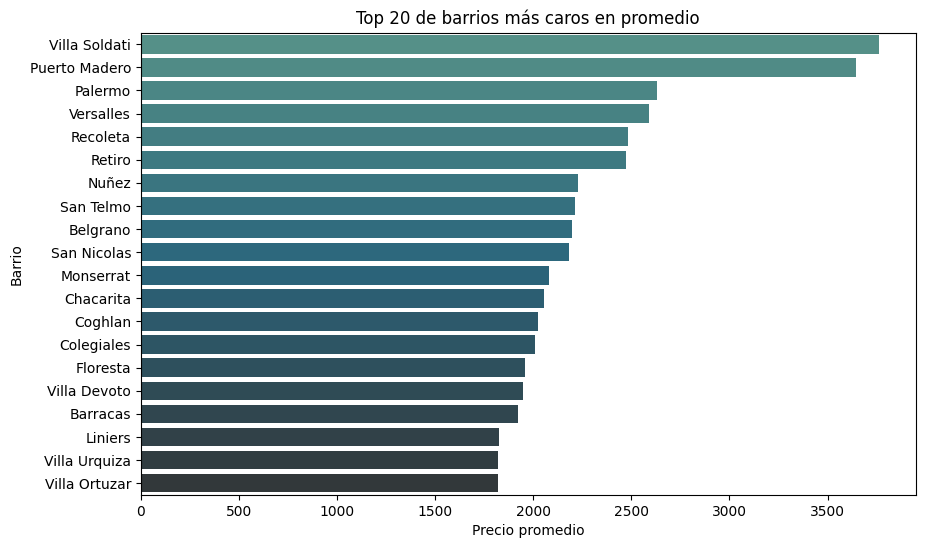

In [13]:
# Top 20 de barrios mas caros en promedio
top_barrios_caros = df.groupby("neighbourhood_cleansed")["price"].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_barrios_caros.values, y=top_barrios_caros.index, palette="crest_d", hue=top_barrios_caros.index)
plt.title("Top 20 de barrios más caros en promedio")
plt.xlabel("Precio promedio")
plt.ylabel("Barrio")
plt.show()

In [14]:
# cantidad de propiedades por barrio
df['neighbourhood_cleansed'].value_counts().head(20)

neighbourhood_cleansed
Palermo          6327
Recoleta         3518
San Nicolas      1280
Balvanera        1124
Retiro           1091
Belgrano         1022
Almagro           940
Monserrat         934
Villa Crespo      752
San Telmo         680
Caballito         444
Nuñez             437
Colegiales        427
Chacarita         385
Constitucion      311
Villa Urquiza     235
Barracas          158
Puerto Madero     144
San Cristobal     142
Saavedra          135
Name: count, dtype: int64

Algunos barrios aparecen inicialmente con precios promedio elevados debido a la baja cantidad de propiedades disponibles, lo que genera promedios poco representativos. 
Para obtener mejores resultados se utilizó la mediana de precios y se filtraron barrios con muy pocas propiedades.

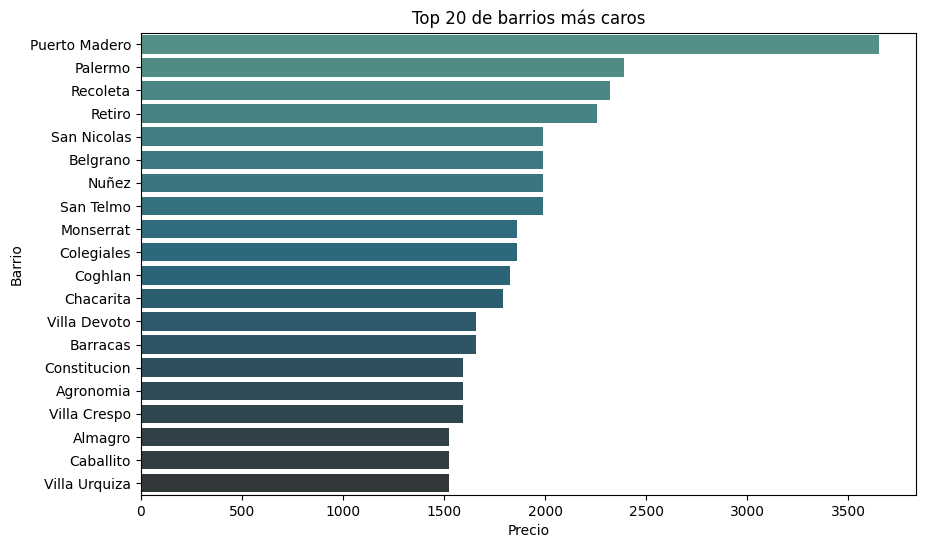

In [15]:
# Top 20 de barrios mas caros
barrios = df.groupby("neighbourhood_cleansed").agg(
    precio_mediano=("price","median"),
    listings=("id","count")
).reset_index()

barrios = barrios[barrios["listings"] > 30]

top_barrios = barrios.sort_values("precio_mediano", ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_barrios,
    x="precio_mediano",
    y="neighbourhood_cleansed",
    palette="crest_d",
    hue="neighbourhood_cleansed"
)
plt.title("Top 20 de barrios más caros")
plt.xlabel("Precio")
plt.ylabel("Barrio")
plt.show()

El gráfico muestra que los precios de los alojamientos estan influenciados por la ubicación. Barrios turísticos y exclusivos como Puerto Madero, Palermo y Recoleta concentran los precios más altos, mientras que zonas más residenciales presentan valores más accesibles. Esto sugiere que la localización es uno de los factores más determinantes en la fijación de precios dentro del mercado de Airbnb.

3. Demanda 

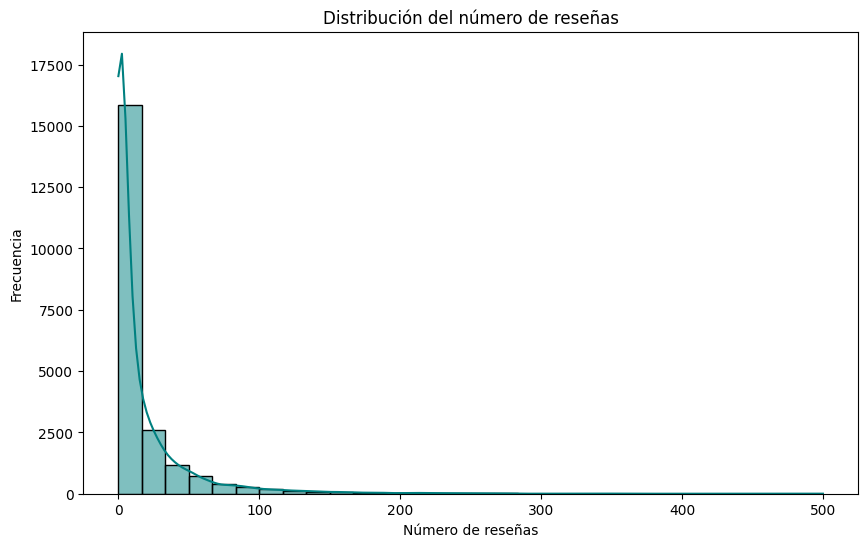

In [16]:
# Distribución del número de reseñas

plt.figure(figsize=(10, 6))
sns.histplot(df["number_of_reviews"], bins=30, kde=True, color='teal')
plt.title("Distribución del número de reseñas")
plt.xlabel("Número de reseñas")
plt.ylabel("Frecuencia")
plt.show()

In [17]:
# Eliminacion de outliers en la columna "number_of_reviews" utilizando el método del rango intercuartílico (IQR)
Q1_reviews = df['number_of_reviews'].quantile(0.25)
Q3_reviews = df['number_of_reviews'].quantile(0.75)
IQR_reviews = Q3_reviews - Q1_reviews
lower_bound_reviews = Q1_reviews - 1.5 * IQR_reviews
upper_bound_reviews = Q3_reviews + 1.5 * IQR_reviews
df = df[(df['number_of_reviews'] >= lower_bound_reviews) & (df['number_of_reviews'] <= upper_bound_reviews)]


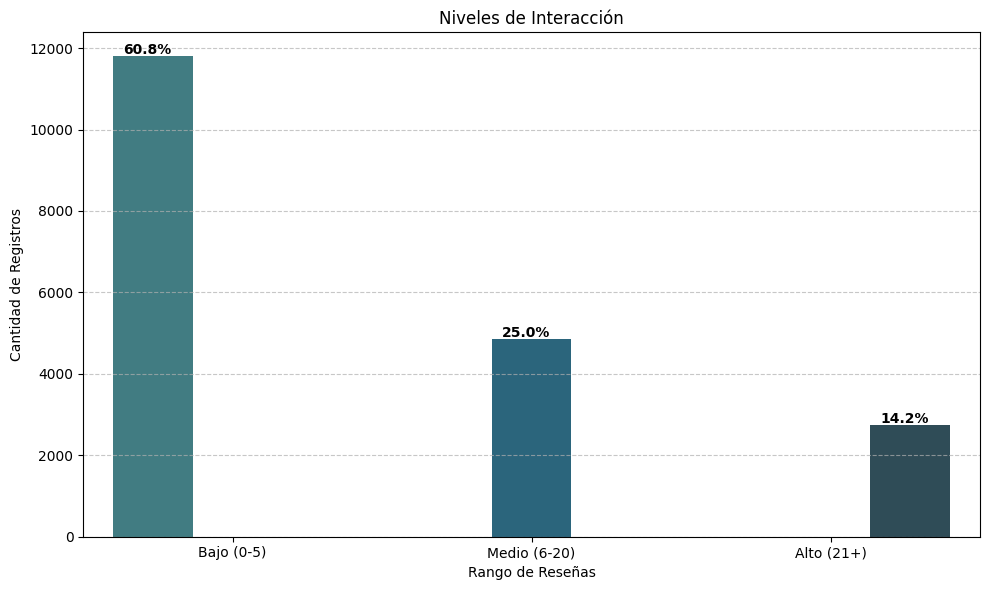

In [18]:
# distribución del número de reseñas después de eliminar outliers

bins = [0, 5, 20, df["number_of_reviews"].max()]
labels = ['Bajo (0-5)', 'Medio (6-20)', 'Alto (21+)']

df['rango_resenas'] = pd.cut(df['number_of_reviews'], bins=bins, labels=labels, include_lowest=True)


plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rango_resenas', palette='crest_d', hue='rango_resenas', legend=False)
plt.title("Niveles de Interacción")
plt.xlabel("Rango de Reseñas")
plt.ylabel("Cantidad de Registros")
plt.grid(axis='y', linestyle='--', alpha=0.7)

total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 50
    plt.annotate(percentage, (x, y), fontweight='bold')

plt.tight_layout()
plt.show()


- El 60.8% de los alojamientos están estancados en el rango "Bajo"
- Un pequeño grupo del 14% tiene una tracción alta esto indica que la mayoría de los hosts son nuevos o tienen baja rotación

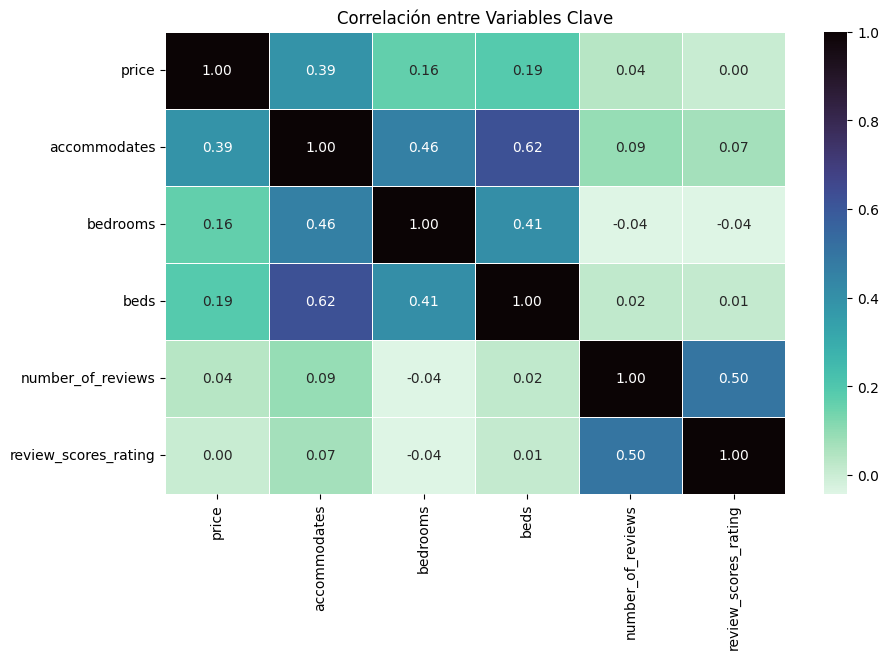

In [19]:
# Correlación entre variables clave

cols_interes = ['price', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
corr = df[cols_interes].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='mako_r', fmt=".2f", linewidths=0.5)
plt.title('Correlación entre Variables Clave')
plt.show()

La variable accommodates es la que más influye en el precio, por encima de la cantidad de habitaciones. Esto sugiere que el mercado valora más cuántas personas pueden dormir en el lugar que la privacidad de los cuartos individuales.

4. Ocupación

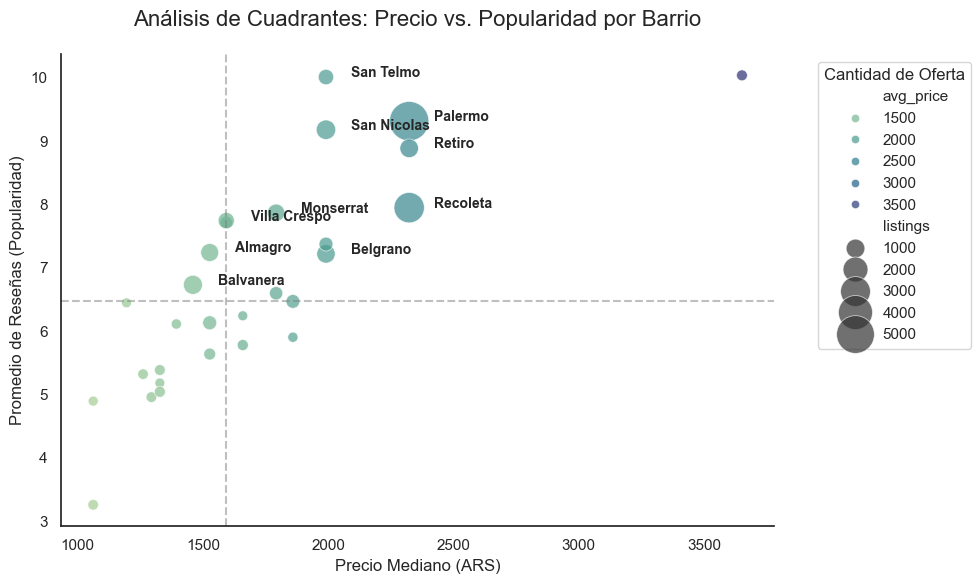

In [20]:
# Visualización de la relación entre precio, número de reseñas y tasa de ocupación por barrio

# 1. Preparación de datos (filtramos barrios con muy pocos listados para no ensuciar)
barrios_stats = df.groupby("neighbourhood_cleansed").agg(
    avg_price=("price", "median"),
    avg_reviews=("number_of_reviews", "mean"),
    listings=("id", "count")
).reset_index()

barrios_stats = barrios_stats[barrios_stats['listings'] > 50]

# 2. Configuración del gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

ax = sns.scatterplot(
    data=barrios_stats,
    x="avg_price",
    y="avg_reviews",
    size="listings",
    hue="avg_price",
    palette="crest", 
    sizes=(50, 800),
    alpha=0.7
)

# 3. Líneas de Cuadrante (Medianas)
plt.axvline(barrios_stats['avg_price'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(barrios_stats['avg_reviews'].median(), color='gray', linestyle='--', alpha=0.5)

# 4. Etiquetamos solo los barrios más importantes
top_barrios = barrios_stats.nlargest(10, 'listings')
for i in range(top_barrios.shape[0]):
    plt.text(
        x=top_barrios.avg_price.iloc[i]+100, 
        y=top_barrios.avg_reviews.iloc[i], 
        s=top_barrios.neighbourhood_cleansed.iloc[i], 
        fontsize=10, weight='semibold'
    )

sns.despine()
plt.title("Análisis de Cuadrantes: Precio vs. Popularidad por Barrio", fontsize=16, pad=20)
plt.xlabel("Precio Mediano (ARS)")
plt.ylabel("Promedio de Reseñas (Popularidad)")
plt.legend(title="Cantidad de Oferta", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

1. Palermo es el líder del Mercado
Se lo ve en el círculo más grande (mayor oferta) y está ubicado en el cuadrante de Alta Popularidad. Aunque su precio es superior a la mediana su nivel de reseñas promedio es muy alto, lo que indica que es una zona "probada" y con mucha rotación.

2. Oportunidad en el Cuadrante Superior Izquierdo
Barrios que están por encima de la línea horizontal pero a la izquierda de la vertical (como quizás San Nicolás o Monserrat), esos son los barrios "eficientes". Tienen precios más bajos que la media pero un volumen de reseñas (demanda) muy alto. Es el segmento ideal para inversores que buscan rotación rápida.

3. Exclusividad en el Cuadrante Inferior Derecho
Los barrios que quedan abajo a la derecha (como Puerto Madero o zonas muy caras de Retiro) son nichos. Tienen los precios más altos del dataset pero un promedio de reseñas más bajo.
No es que les vaya mal sino que su modelo de negocio es "poca rotación, alto margen".

5. Analisis del Host

In [21]:
# Ingresos estimados por superhost
df.groupby("host_is_superhost")["estimated_revenue"].median()

host_is_superhost
0.0    222083.0
1.0    259284.0
Name: estimated_revenue, dtype: float64

No existe una diferencia significativa entre ser superhost o host.

In [22]:
# Exportación del dataframe limpio para usarlo en el dashboard en Power BI
df.to_csv('../data/listings_para_dashboard.csv')

Conclusiones del Análisis de Mercado Airbnb

Tras el procesamiento y análisis exploratorio del dataset de alojamientos se tienen los siguientes insights:

1. Concentración y saturación: El mercado esta fuertemente centralizado en la zona centro-norte (Palermo y Recoleta concentran más del 40% de la oferta). Esto sugiere una demanda validada pero una competencia alta que obliga a los nuevos ingresos a competir por precio o por calidad de reseñas.

2. Segmentación de popularidad: Se identifica que el 60.8% de los listados se encuentran en un nivel de interacción "Bajo" (0-5 reseñas). Esto representa una oportunidad, los hosts que logren superar las 20 reseñas entran en un segmento de "Elite" (Top 14%) donde la tracción de reservas se vuelve orgánica.

3. Drivers de precio: La capacidad de huéspedes (accommodates) tiene mas relación con el precio que la cantidad de dormitorios. Para maximizar el Estimated Revenue la estrategia es optimizar el espacio para recibir más personas (por ejemplo con algún sofácama) antes que invertir en infraestructura de habitaciones privadas.

4. Zonas de oportunidad: El análisis de cuadrantes revela barrios como San Nicolás o Monserrat con una relación precio/popularidad eficiente. Son zonas con menor costo de entrada que Palermo pero con niveles de rotación (reseñas) similares o superiores.

Por último, el dataset ha sido normalizado y exportado para su visualización en Power BI donde se profundizará en:
- Análisis geoespacial de la rentabilidad.
- Comparativa de KPIs por tipo de propiedad.
- Dashboard interactivo para la toma de decisiones de inversión.